In [ ]:
!pip install tensorflow|

/bin/bash: -c: line 2: syntax error: unexpected end of file


Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1390/1390 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.2803 - loss: 1.8698 - val_accuracy: 0.4419 - val_loss: 1.5174
Epoch 2/50
1390/1390 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.4538 - loss: 1.4536 - val_accuracy: 0.4972 - val_loss: 1.3197
Epoch 3/50
1390/1390 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5185 - loss: 1.2702 - val_accuracy: 0.5383 - val_loss: 1.2077
Epoch 4/50
1390/1390 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5551 - loss: 1.1711 - val_accuracy: 0.5715 - val_loss: 1.1333
Epoch 5/50
1390/1390 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5863 - loss: 1.0944 - val_accuracy: 0.5891 - val_loss: 1.0835
Epoch 6/50
1390/1390 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6157 - loss: 1.0352 - val_accuracy: 0.6350 - val_loss: 1.0333
Epoch 7/50
1390/1390 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6419 - loss: 0.9820 - val_accuracy: 0.6376 - val_loss: 0.9899
Epoch 8/50
1390/1390 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6583 - loss: 0.9346 - val_accurac

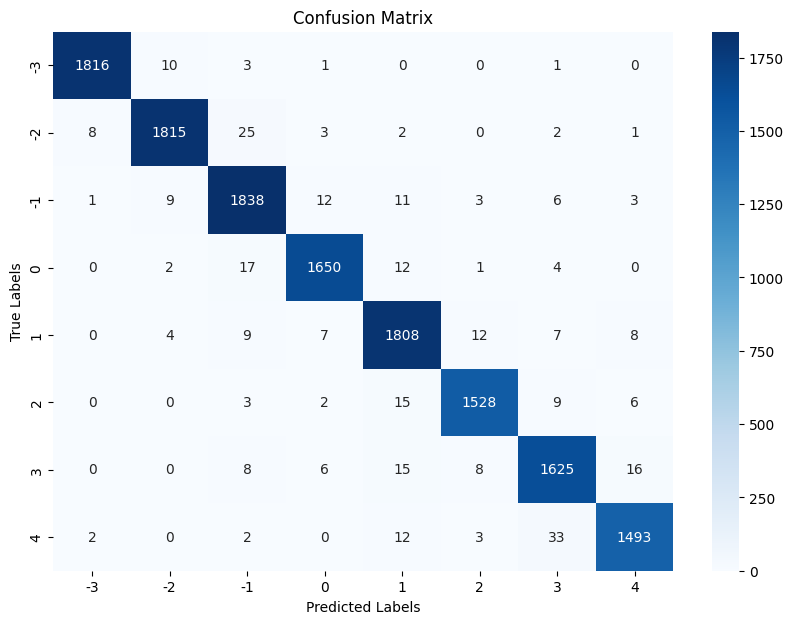

InvalidParameterError: The 'y_true' parameter of roc_curve must be an array-like. Got <13897x1 sparse matrix of type '<class 'numpy.float64'>'
	with 1831 stored elements in Compressed Sparse Row format> instead.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

path = 'drive/MyDrive/Fall 2024/SEED'
# Load and preprocess data (same as before)
data1 = pd.read_csv(f'{path}/annsouthworthL.csv')
data2 = pd.read_csv(f'{path}/johndyerL.csv')
data3 = pd.read_csv(f'{path}/hayleysavageL.csv')
data4 = pd.read_csv(f'{path}/laurenmillerL.csv')
data5 = pd.read_csv(f'{path}/michaeltylendaL.csv')
data6 = pd.read_csv(f'{path}/saramcmillanL.csv')
data7 = pd.read_csv(f'{path}/toniboltzL.csv')
data8 = pd.read_csv(f'{path}/annsouthworthR.csv')
data9 = pd.read_csv(f'{path}/johndyerR.csv')
data10 = pd.read_csv(f'{path}/hayleysavageR.csv')
data11 = pd.read_csv(f'{path}/laurenmillerR.csv')
data12 = pd.read_csv(f'{path}/michaeltylendaR.csv')
data13 = pd.read_csv(f'{path}/saramcmillanR.csv')
data14 = pd.read_csv(f'{path}/toniboltzR.csv')

headerList = ['acc x-axis', 'acc y-axis', 'acc z-axis',
              'gyro x-axis', 'gyro y-axis', 'gyro z-axis',
              'magno x-axis', 'magno y-axis', 'magno z-axis',
              'notsure1', 'notsure2', 'notsure3', 'RASS']

data1.columns = headerList
data2.columns = headerList
data3.columns = headerList
data4.columns = headerList
data5.columns = headerList
data6.columns = headerList
data7.columns = headerList
data8.columns = headerList
data9.columns = headerList
data10.columns = headerList
data11.columns = headerList
data12.columns = headerList
data13.columns = headerList
data14.columns = headerList

combined_data = pd.concat([data1, data2, data3, data4, data5, data6, data7, data8, data9, data10, data11, data12, data13, data14], ignore_index=True)

X = combined_data[['acc x-axis', 'acc y-axis', 'acc z-axis',
                   'gyro x-axis', 'gyro y-axis', 'gyro z-axis',
                   'magno x-axis', 'magno y-axis', 'magno z-axis']]
y = combined_data['RASS']

# Fill missing values
X = X.fillna(X.mean())
y = y.fillna(y.mode()[0])

# Apply Moving Average Smoothing
window_size = 5  # Adjust based on your needs
X_smoothed = X.rolling(window=window_size, min_periods=1).mean()

# Apply Z-score normalization to remove outliers
from scipy import stats
z_scores = np.abs(stats.zscore(X_smoothed))
X_cleaned = X_smoothed[(z_scores < 3).all(axis=1)]  # Retain only data within 3 standard deviations
y_cleaned = y[X_cleaned.index]  # Keep corresponding target values

# One-Hot Encoding of the RASS score
encoder = OneHotEncoder()
y_encoded = encoder.fit_transform(y_cleaned.values.reshape(-1, 1))

# Standard Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cleaned)

# Data Splitting
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42)

# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=1000, random_state=42)
rf_model.fit(X_train, np.asarray(np.argmax(y_train, axis=1)).ravel())

# Train Neural Network
nn_model = Sequential()
nn_model.add(Dense(64, input_dim=X_train.shape[1], activation='relu'))
nn_model.add(Dense(32, activation='relu'))
nn_model.add(Dense(y_encoded.shape[1], activation='softmax'))
nn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
# Convert y_train to a dense array
y_train_dense = y_train.toarray()
nn_model.fit(X_train, y_train_dense, epochs=50, batch_size=32, validation_split=0.2, verbose=1)

# Generate predictions
rf_preds = rf_model.predict(X_test)
nn_preds = nn_model.predict(X_test)

# Stack predictions
rf_preds_proba = np.eye(y_encoded.shape[1])[rf_preds]  # Convert to one-hot encoding
stacked_features = np.hstack([rf_preds_proba, nn_preds])

# Train meta-model
meta_model = LogisticRegression(max_iter=1000)
meta_model.fit(stacked_features, np.asarray(np.argmax(y_test, axis=1)).ravel())

# Make final predictions
rf_test_preds = rf_model.predict(X_test)
nn_test_preds = nn_model.predict(X_test)
rf_test_preds_proba = np.eye(y_encoded.shape[1])[rf_test_preds]
stacked_test_features = np.hstack([rf_test_preds_proba, nn_test_preds])
final_preds = meta_model.predict(stacked_test_features)

# Convert back to original RASS categories
y_pred_labels = encoder.categories_[0][final_preds]
y_test_labels = encoder.categories_[0][np.argmax(y_test, axis=1)]

# Evaluate performance
print(f'Accuracy: {accuracy_score(y_test_labels, y_pred_labels):.2f}')
print('Classification Report:')
print(classification_report(y_test_labels, y_pred_labels))

# Calculate and display confusion matrix
cm = confusion_matrix(y_test_labels, y_pred_labels, labels=encoder.categories_[0])
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=encoder.categories_[0], yticklabels=encoder.categories_[0])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

# ROC Curve
n_classes = y_encoded.shape[1]
fpr = dict()
tpr = dict()
roc_auc = dict()

# Compute ROC curve and ROC area for each class
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], nn_preds[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure()
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {encoder.categories_[0][i]} (area = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (area = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# save the models
import joblib

# Save the Random Forest model
joblib.dump(rf_model, f'{path}/rf_model.pkl')
# save neural network model
nn_model.save(f'{path}/nn_model.keras')